# Imports

In [1]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from itertools import product

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.backends.backend_pdf import PdfPages
from tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group, exist_pred

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Snapshots

## load data

In [9]:
data = {}
weights = {}
projection_dir = '/data/home/Licheng/workspace/TSF-PCA/projections/PCA'
datasets = ['ETTh1_PCA', 'ETTh2_PCA', 'ETTm1_PCA', 'ETTm2_PCA', 'ECL_PCA', 'Traffic_PCA', 'Weather_PCA']

for data_id in datasets:
    for pred_len in [96, 192, 336, 720]:
        root = os.path.join(projection_dir, data_id, str(pred_len))
        pca_components = load_npy(os.path.join(root, 'pca_components.npy'))
        label_seq = load_npy(os.path.join(root, 'label_seq.npy'))
        # print("PCA components shape:", pca_components.shape)
        # print("Label sequence shape:", label_seq.shape)
        label = label_seq[..., -1]
        components = pca_components[-1]
        projection = np.dot(label, components.T)
        mean_components = np.mean(projection, axis=0)
        data[f"{data_id}_{pred_len}"] = mean_components
        del pca_components, label_seq, label, components, projection
        
        weight = load_npy(os.path.join(root, 'weights.npy'))
        weights[f"{data_id}_{pred_len}"] = weight[-1]
        del weight


In [ ]:
for k, v in data.items():
    if isinstance(v, list):
        print(k, v[0].shape, v[1].shape)
    else:
        print(k, v.shape)

## plot

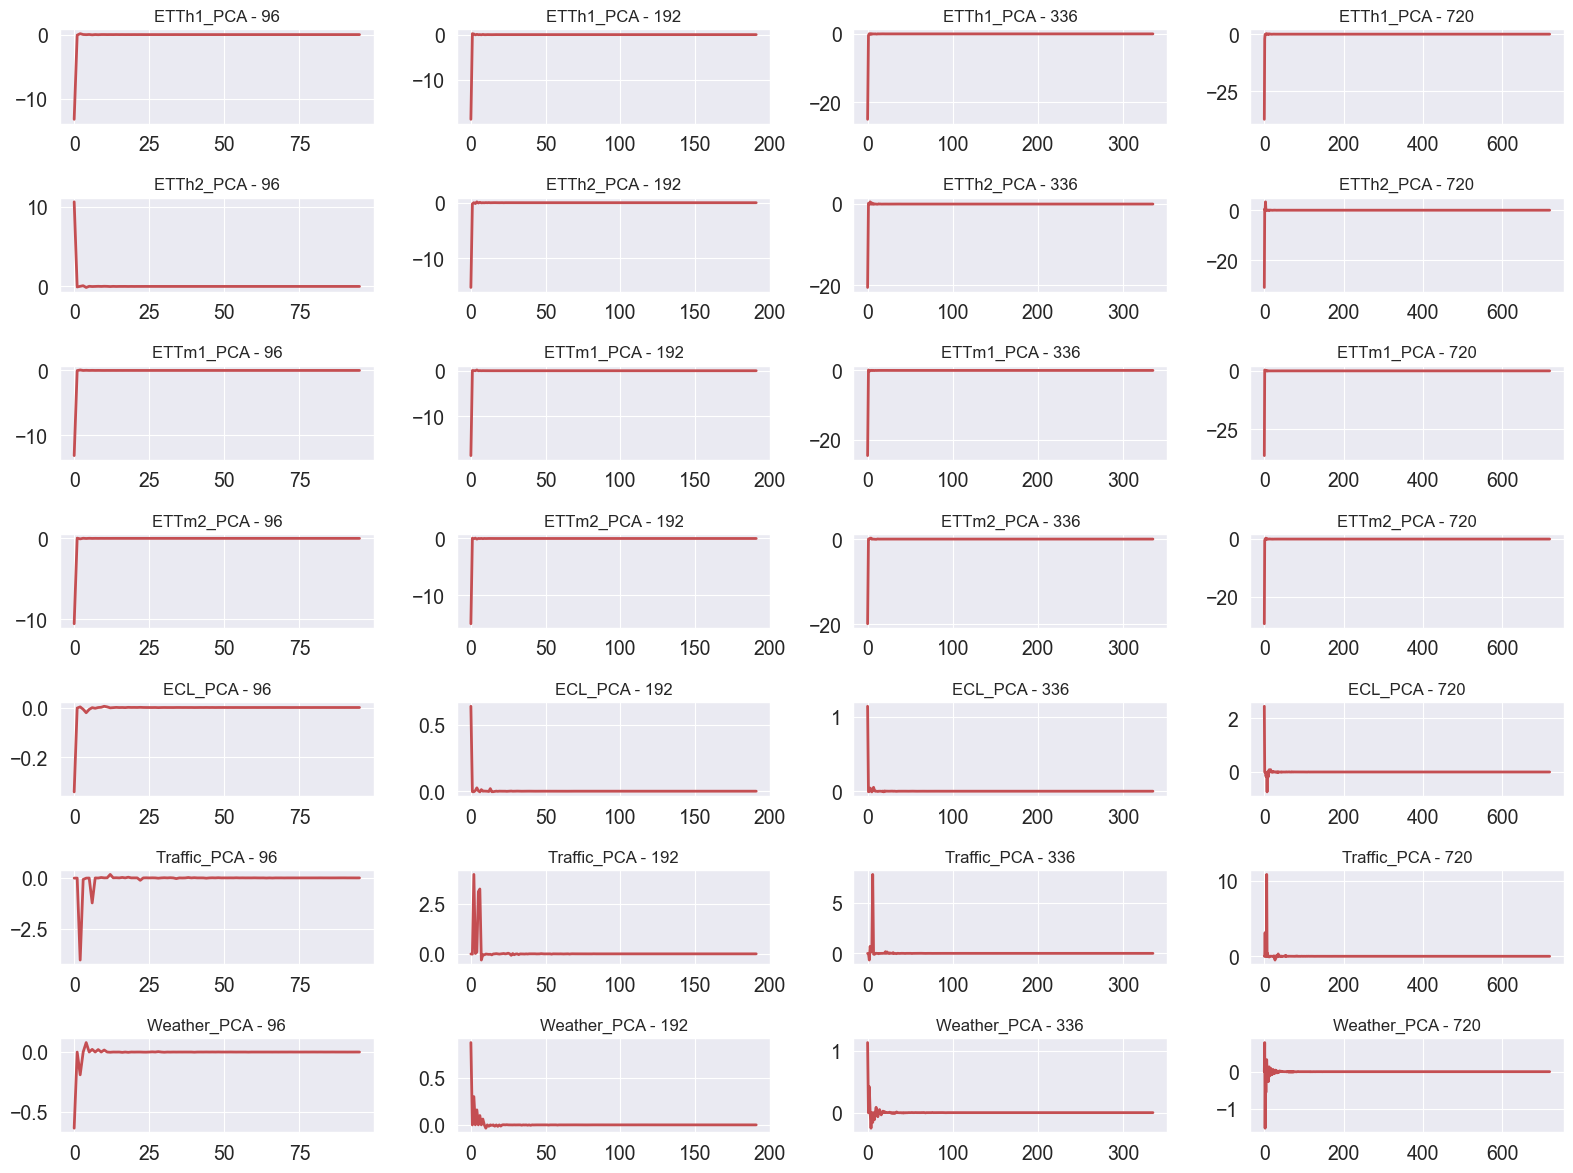

In [3]:
legend_location = 'upper left'
labelsize = 12

style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
context = ['paper', 'notebook', 'talk', 'poster']
palette = sns.color_palette('deep')
palette = [palette[3], palette[0], palette[2]] + palette[4:]
sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

f = plt.figure(dpi=100, figsize=(16, 12))  # 如果只画一条线，就用红色，高改为3->2.5
f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)


for i, data_id in enumerate(datasets):
    for j, pred_len in enumerate([96, 192, 336, 720]):
        f.add_subplot(7, 4, i * 4 + j + 1)
        key = f"{data_id}_{pred_len}"
        plt.plot(data[key], label=key, linewidth=2)
        plt.title(f"{data_id} - {pred_len}", fontsize=labelsize)

plt.tight_layout()
plt.show()

## plot variance

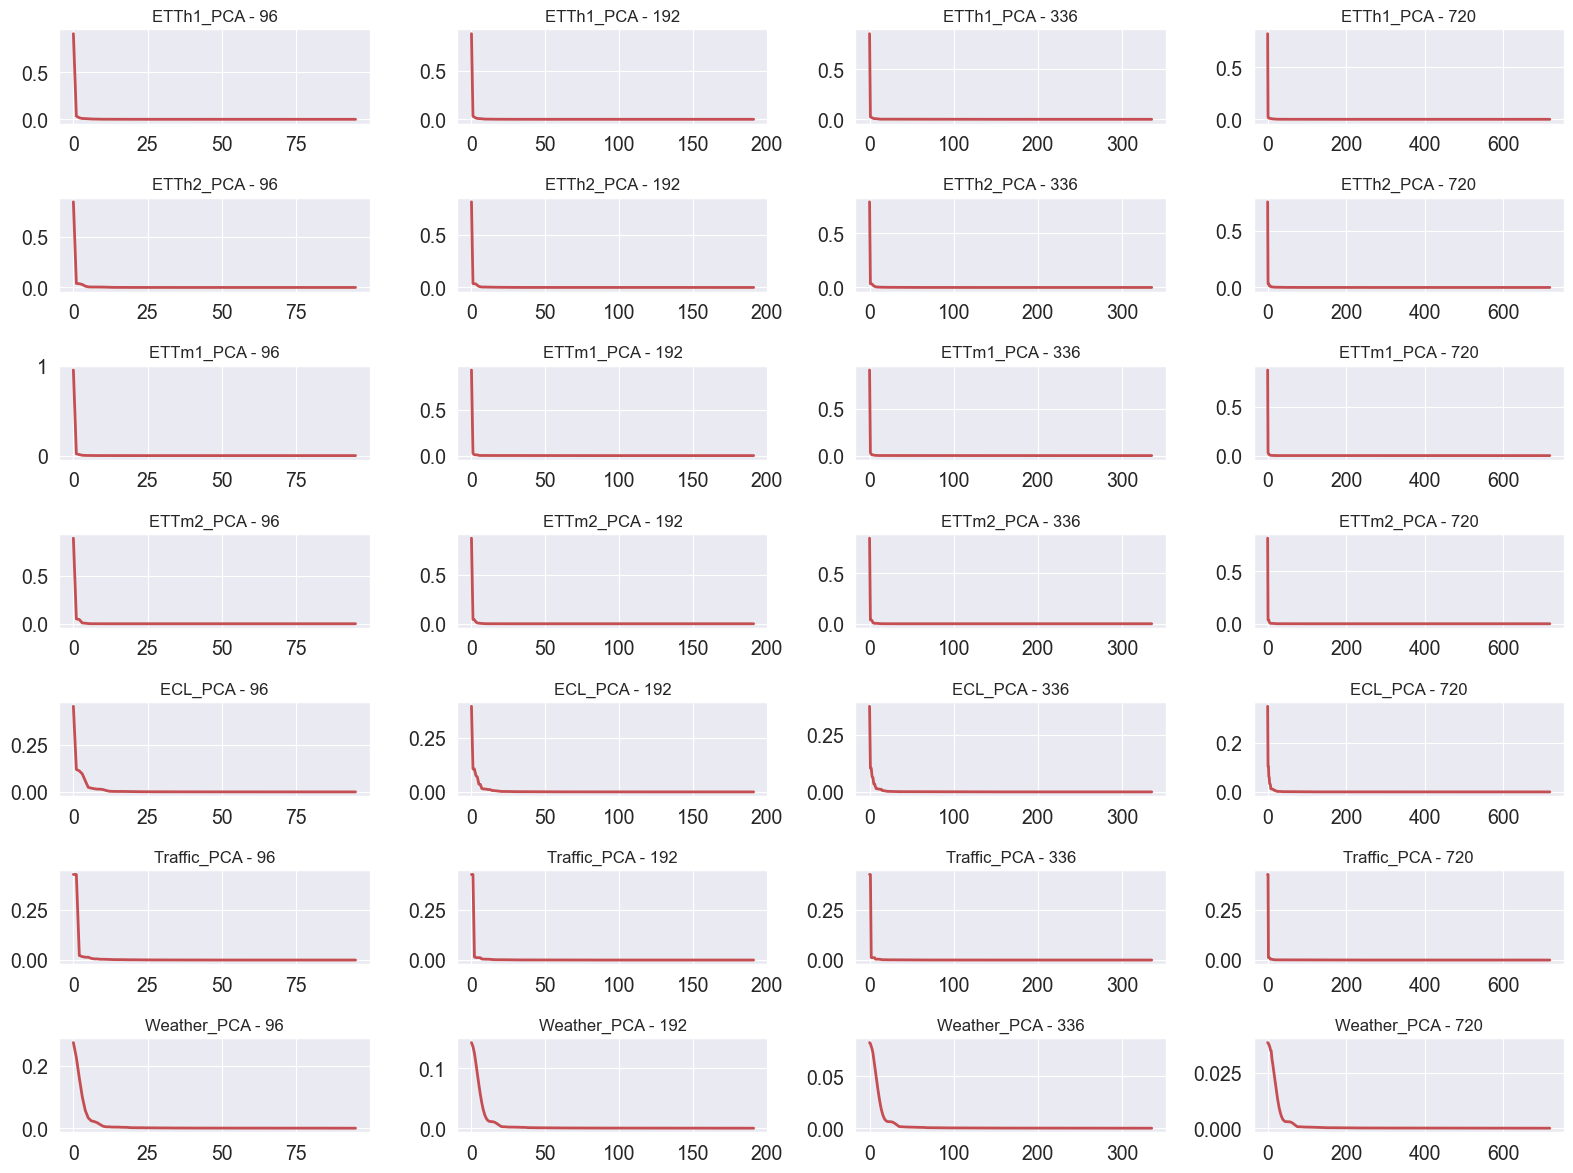

In [10]:
legend_location = 'upper left'
labelsize = 12

style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
context = ['paper', 'notebook', 'talk', 'poster']
palette = sns.color_palette('deep')
palette = [palette[3], palette[0], palette[2]] + palette[4:]
sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

f = plt.figure(dpi=100, figsize=(16, 12))  # 如果只画一条线，就用红色，高改为3->2.5
f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)


for i, data_id in enumerate(datasets):
    for j, pred_len in enumerate([96, 192, 336, 720]):
        f.add_subplot(7, 4, i * 4 + j + 1)
        key = f"{data_id}_{pred_len}"
        plt.plot(weights[key], label=key, linewidth=2)
        plt.title(f"{data_id} - {pred_len}", fontsize=labelsize)

plt.tight_layout()
plt.show()